# Generative AI for Medical Data Augmentation using GANs

This project investigates the use of WGAN-GP-generated synthetic chest X-ray images for improving pneumonia detection performance.

Pipeline:

Dataset → WGAN-GP → Synthetic Images → DenseNet Feature Filtering → Augmented Dataset → DenseNet121 Classifier → Streamlit UI

Key Components:

* WGAN-GP for image generation
* DenseNet121 feature-based filtering
* Pneumonia classification
* Ablation study
* ROC-AUC and Precision-Recall evaluation
* Streamlit deployment


# Environment Setup

This project was developed in Google Colab using Google Drive storage.

Before running:

1. Mount Google Drive
2. Download the Chest X-ray Pneumonia Dataset
3. Update dataset and output paths according to your environment

Example:

DATASET_DIR = "/content/drive/MyDrive/chest_xray"

PROJECT_DIR = "/content/drive/MyDrive/generative_ai_project"

# Dataset Preparation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install -q streamlit kaggle

In [ ]:
# Upload kaggle.json file
from google.colab import files
files.upload()

In [ ]:
!mkdir -p /content/drive/MyDrive/chest_xray

In [ ]:
# Place kaggle.json in ~/.kaggle before running.
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/drive/MyDrive/chest_xray

In [ ]:
!unzip -q /content/drive/MyDrive/chest_xray/chest-xray-pneumonia.zip -d /content/drive/MyDrive/chest_xray

In [ ]:
%cd /content/drive/MyDrive/chest_xray
!mv chest_xray/chest_xray /content/drive/MyDrive/data_temp
%cd /content/drive/MyDrive
!rm -rf chest_xray
!mv data_temp chest_xray
!rm -rf chest_xray/__MACOSX

In [ ]:
!mkdir -p /content/drive/MyDrive/generative_ai_project

# GAN Training

In [ ]:
%%writefile train_wgangp_perceptual_clean.py

import os
import argparse
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.utils import save_image
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from scipy import linalg

# ============================================================
# 1) CONFIGURATION
# ============================================================
DRIVE_DIR = "/content/drive/MyDrive/generative_ai_project"
TRAIN_DIR = "/content/drive/MyDrive/chest_xray/train"
OUTPUT_DIR = os.path.join(DRIVE_DIR, "output_images")
CKPT_DIR = os.path.join(DRIVE_DIR, "checkpoints")
BEST_MODEL_PATH = os.path.join(DRIVE_DIR, "best_generator.pth")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# ============================================================
# 2) MODEL BUILDING BLOCKS
# ============================================================
class Generator(nn.Module):
    def __init__(self, z_dim=256):
        super().__init__()

        self.init = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True)
        )

        self.upsample_blocks = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(512, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(256, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(128, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(64, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(32, 1, 3, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.init(z)
        return self.upsample_blocks(x)


def spectral_norm(layer):
    return nn.utils.spectral_norm(layer)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            spectral_norm(nn.Conv2d(1, 32, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(32, 64, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(64, 128, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(128, 256, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            spectral_norm(nn.Conv2d(256, 512, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.head = spectral_norm(nn.Conv2d(512, 1, 4, 1, 0, bias=False))

    def forward(self, x):
        feat = self.features(x)
        out = self.head(feat).view(-1)
        return out, feat

# ============================================================
# 3) HELPER FUNCTIONS
# ============================================================
def gradient_penalty(D, real, fake, device, lambda_gp=10.0):
    batch_size = real.size(0)
    epsilon = torch.rand(batch_size, 1, 1, 1, device=device)

    mixed = epsilon * real + (1.0 - epsilon) * fake
    mixed.requires_grad_(True)

    mixed_out, _ = D(mixed)
    gradients = torch.autograd.grad(
        outputs=mixed_out.sum(),
        inputs=mixed,
        create_graph=True
    )[0]

    gradients = gradients.view(batch_size, -1)
    gp = ((gradients.norm(2, dim=1) - 1.0) ** 2).mean() * lambda_gp
    return gp


def compute_pairwise_ssim(images):
    n = images.shape[0]
    values = []

    for i in range(n):
        for j in range(i + 1, n):
            values.append(ssim(images[i], images[j], data_range=1.0))

    return float(np.mean(values)) if values else 0.0


def get_densenet_encoder(device):
    return models.densenet121(pretrained=True).features.to(device).eval()


def extract_feature_vectors(encoder, images):
    with torch.no_grad():
        x = (images + 1.0) / 2.0
        x = x.repeat(1, 3, 1, 1)

        mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1, 3, 1, 1)

        x = (x - mean) / std
        feats = encoder(x)
        feats = feats.view(feats.size(0), feats.size(1), -1).mean(dim=2)

    return feats

# ============================================================
# 4) TRAINING
# ============================================================
def train(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    tf = transforms.Compose([
        transforms.Resize((args.image_size, args.image_size)),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    dataset = datasets.ImageFolder(root=args.train_dir, transform=tf)

    if "NORMAL" not in dataset.class_to_idx:
        raise RuntimeError("NORMAL folder not found in train_dir")

    normal_idx = dataset.class_to_idx["NORMAL"]
    dataset.samples = [s for s in dataset.samples if s[1] == normal_idx]
    dataset.targets = [s[1] for s in dataset.samples]

    print(f"Training on NORMAL images only: {len(dataset)} images")

    loader = DataLoader(
        dataset,
        batch_size=args.batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    G = Generator(z_dim=args.latent_dim).to(device)
    D = Discriminator().to(device)
    encoder = get_densenet_encoder(device)

    if args.resume_epoch > 0:
        ckpt_path = os.path.join(CKPT_DIR, f"checkpoint_epoch_{args.resume_epoch:03d}.pth")
        if os.path.exists(ckpt_path):
            print(f"Loading checkpoint: {ckpt_path}")
            ckpt = torch.load(ckpt_path, map_location=device)
            G.load_state_dict(ckpt["G"])
            D.load_state_dict(ckpt["D"])
        else:
            print("Checkpoint not found. Starting from scratch.")

    optG = optim.Adam(G.parameters(), lr=args.lr_g, betas=(0.0, 0.9))
    optD = optim.Adam(D.parameters(), lr=args.lr_d, betas=(0.0, 0.9))

    fixed_noise = torch.randn(64, args.latent_dim, 1, 1, device=device)
    best_fid = float("inf")
    global_step = 0

    def save_samples(epoch):
        G.eval()
        with torch.no_grad():
            fake = G(fixed_noise).cpu()
        save_image(
            fake,
            os.path.join(OUTPUT_DIR, f"fake_samples_epoch_{epoch:03d}.png"),
            nrow=8,
            normalize=True
        )
        G.train()

    for epoch in range(args.start_epoch, args.epochs + 1):
        pbar = tqdm(loader, desc=f"Epoch {epoch}/{args.epochs}")

        for real_batch in pbar:
            real = real_batch[0].to(device)
            batch_size = real.size(0)

            # --------------------------------
            # Step 1: Train Discriminator
            # --------------------------------
            for _ in range(args.critic_steps):
                z = torch.randn(batch_size, args.latent_dim, 1, 1, device=device)
                fake = G(z).detach()

                D.zero_grad()
                out_real, feat_real = D(real)
                out_fake, feat_fake = D(fake)

                wasserstein_loss = out_fake.mean() - out_real.mean()
                gp = gradient_penalty(D, real, fake, device, lambda_gp=args.lambda_gp)
                loss_D = wasserstein_loss + gp

                loss_D.backward()
                optD.step()

            # --------------------------------
            # Step 2: Train Generator
            # --------------------------------
            G.zero_grad()
            z = torch.randn(batch_size, args.latent_dim, 1, 1, device=device)
            fake = G(z)

            out_fake_for_g, feat_fake_for_g = D(fake)
            adv_loss = -out_fake_for_g.mean()

            with torch.no_grad():
                _, feat_real_for_fm = D(real)

            fm_loss = F.l1_loss(
                feat_fake_for_g.mean(dim=(0, 2, 3)),
                feat_real_for_fm.mean(dim=(0, 2, 3))
            )

            real_features = extract_feature_vectors(encoder, real)
            fake_features = extract_feature_vectors(encoder, fake)
            perc_loss = F.mse_loss(fake_features, real_features)

            loss_G = adv_loss + args.lambda_fm * fm_loss + args.lambda_perc * perc_loss
            loss_G.backward()
            optG.step()

            global_step += 1

            if global_step % args.log_every == 0:
                with torch.no_grad():
                    sample_grid = G(fixed_noise).detach().cpu().numpy()
                    sample_grid = (sample_grid[:, 0, :, :] + 1.0) / 2.0
                    ssim_score = compute_pairwise_ssim(sample_grid)

                pbar.set_postfix({
                    "D": round(loss_D.item(), 4),
                    "G": round(loss_G.item(), 4),
                    "FM": round(fm_loss.item(), 4),
                    "Perc": round(perc_loss.item(), 4),
                    "SSIM": round(ssim_score, 4)
                })

        # --------------------------------
        # Step 3: Save outputs for the epoch
        # --------------------------------
        save_samples(epoch)

        torch.save(
            {"G": G.state_dict(), "D": D.state_dict()},
            os.path.join(CKPT_DIR, f"checkpoint_epoch_{epoch:03d}.pth")
        )

        # FID-like score
        with torch.no_grad():
            real_samples = []
            seen = 0
            for xb, _ in loader:
                real_samples.append(xb)
                seen += xb.size(0)
                if seen >= 256:
                    break

            real_samples = torch.cat(real_samples, dim=0)[:256].to(device)
            fake_samples = G(torch.randn(min(256, args.sample_n), args.latent_dim, 1, 1, device=device))

            real_vecs = extract_feature_vectors(encoder, real_samples).cpu().numpy()
            fake_vecs = extract_feature_vectors(encoder, fake_samples).cpu().numpy()

            mu_r = real_vecs.mean(axis=0)
            mu_f = fake_vecs.mean(axis=0)
            cov_r = np.cov(real_vecs, rowvar=False)
            cov_f = np.cov(fake_vecs, rowvar=False)

            covmean = linalg.sqrtm(cov_r.dot(cov_f))
            if np.iscomplexobj(covmean):
                covmean = covmean.real

            fid_like = np.sum((mu_r - mu_f) ** 2) + np.trace(cov_r + cov_f - 2 * covmean)

        print(f"Epoch {epoch}: FID-like = {fid_like:.3f}")

        if fid_like < best_fid:
            best_fid = fid_like
            torch.save(
                {
                    "epoch": epoch,
                    "model": G.state_dict(),
                    "fid": fid_like
                },
                BEST_MODEL_PATH
            )
            print(f"Best model saved at epoch {epoch} with FID-like = {fid_like:.3f}")

    print("Training complete.")
    print(f"Best generator saved at: {BEST_MODEL_PATH}")

# ============================================================
# 5) ENTRY POINT
# ============================================================
if __name__ == "__main__":
    parser = argparse.ArgumentParser()

    parser.add_argument("--train_dir", type=str, default=TRAIN_DIR)
    parser.add_argument("--epochs", type=int, default=30)
    parser.add_argument("--start_epoch", type=int, default=1)
    parser.add_argument("--resume_epoch", type=int, default=0)

    parser.add_argument("--image_size", type=int, default=128)
    parser.add_argument("--batch_size", type=int, default=16)
    parser.add_argument("--latent_dim", type=int, default=256)

    parser.add_argument("--lr_d", type=float, default=1e-4)
    parser.add_argument("--lr_g", type=float, default=1e-4)

    parser.add_argument("--critic_steps", type=int, default=5)
    parser.add_argument("--lambda_gp", type=float, default=10.0)
    parser.add_argument("--lambda_fm", type=float, default=1.0)
    parser.add_argument("--lambda_perc", type=float, default=3.0)

    parser.add_argument("--log_every", type=int, default=200)
    parser.add_argument("--sample_n", type=int, default=128)

    args = parser.parse_args()
    train(args)

In [ ]:
!python train_wgangp_perceptual_clean.py \
    --epochs 50 \
    --batch_size 16 \
    --latent_dim 256

In [ ]:
!python train_wgangp_perceptual_clean.py \
    --epochs 100 \
    --resume_epoch 50 \
    --start_epoch 51 \
    --batch_size 16 \
    --latent_dim 256

In [ ]:
!python train_wgangp_perceptual_clean.py \
    --epochs 110 \
    --resume_epoch 100 \
    --start_epoch 101 \
    --batch_size 16 \
    --latent_dim 256

# Synthetic Image Generation & Image Filtering

In [ ]:
%%writefile generate_and_filter.py

import os, argparse, torch, shutil
from torchvision.utils import save_image
from torchvision import transforms, models
from PIL import Image
import numpy as np
from tqdm import tqdm
import torch.nn as nn

# ==============================
# 1. CONFIG
# ==============================
DRIVE = '/content/drive/MyDrive/generative_ai_project'
GEN_OUT = os.path.join(DRIVE, 'generated_images', 'train', 'NORMAL')
FILTERED_OUT = os.path.join(DRIVE, 'generated_images', 'filtered_NORMAL')

# ==============================
# 2. GENERATOR (MATCH TRAINING)
# ==============================
class Generator(nn.Module):
    def __init__(self, z_dim=256):
        super().__init__()

        self.init = nn.Sequential(
            nn.ConvTranspose2d(z_dim,512,4,1,0,bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True)
        )

        self.upsample_blocks = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(512,256,3,padding=1,bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(256,128,3,padding=1,bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(128,64,3,padding=1,bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(64,32,3,padding=1,bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(32,1,3,padding=1,bias=False),
            nn.Tanh()
        )

    def forward(self,x):
        x = self.init(x)
        return self.upsample_blocks(x)


# ==============================
# 3. FEATURE EXTRACTION
# ==============================
def extract_feats(folder, model, tf, device):
    files = sorted([os.path.join(folder,f) for f in os.listdir(folder) if f.endswith(('.png','.jpg','.jpeg'))])
    feats = []

    for f in tqdm(files, desc=f"Extracting: {os.path.basename(folder)}"):
        im = Image.open(f).convert('L')
        x = tf(im).unsqueeze(0).to(device)

        with torch.no_grad():
            x = x.repeat(1,3,1,1)
            feat = model(x)
            feat = feat.view(feat.size(0), feat.size(1), -1).mean(dim=2)
            feats.append((f, feat.squeeze().cpu().numpy()))

    return feats


# ==============================
# 4. MAIN
# ==============================
if __name__ == '__main__':
    parser = argparse.ArgumentParser()
    parser.add_argument('--checkpoint', required=True)
    parser.add_argument('--n', type=int, default=2500)
    parser.add_argument('--keep_k', type=int, default=2000)
    parser.add_argument('--batch', type=int, default=16)
    args = parser.parse_args()

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # ==============================
    # CLEAN OLD DATA
    # ==============================
    if os.path.exists(GEN_OUT):
        shutil.rmtree(GEN_OUT)
    if os.path.exists(FILTERED_OUT):
        shutil.rmtree(FILTERED_OUT)

    os.makedirs(GEN_OUT, exist_ok=True)
    os.makedirs(FILTERED_OUT, exist_ok=True)

    # ==============================
    # LOAD GENERATOR
    # ==============================
    print("Loading generator...")
    G = Generator().to(device)

    ck = torch.load(args.checkpoint, map_location=device, weights_only=False)
    G.load_state_dict(ck["model"])
    G.eval()

    # ==============================
    # GENERATE IMAGES
    # ==============================
    print(f"Generating {args.n} images...")
    count = 0

    with tqdm(total=args.n) as pbar:
        while count < args.n:
            bs = min(args.batch, args.n - count)
            z = torch.randn(bs, 256, 1, 1, device=device)

            with torch.no_grad():
                imgs = G(z).cpu()

            for i in range(bs):
                save_image(imgs[i],
                           os.path.join(GEN_OUT, f"synthetic_{count+i:05d}.png"),
                           normalize=True)

            count += bs
            pbar.update(bs)

    print("Generation complete.")

    # ==============================
    # LOAD FEATURE MODEL
    # ==============================
    print("Loading DenseNet...")
    feat_model = models.densenet121(pretrained=True).features.to(device).eval()

    tf = transforms.Compose([
        transforms.Resize((128,128)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,),(0.5,))
    ])

    # ==============================
    # REAL FEATURES
    # ==============================
    real_dir = '/content/drive/MyDrive/chest_xray/train/NORMAL'
    print("Extracting real features...")
    real_feats = extract_feats(real_dir, feat_model, tf, device)
    centroid = np.mean([f for _,f in real_feats], axis=0)

    # ==============================
    # GENERATED FEATURES
    # ==============================
    print("Extracting generated features...")
    gen_feats = extract_feats(GEN_OUT, feat_model, tf, device)

    distances = [(np.linalg.norm(vec - centroid), path) for path, vec in gen_feats]
    distances.sort()

    # ==============================
    # FILTER BEST
    # ==============================
    keep = distances[:args.keep_k]

    print(f"Keeping {len(keep)} best images...")

    for _, p in tqdm(keep, desc="Filtering"):
        shutil.copy(p, os.path.join(FILTERED_OUT, os.path.basename(p)))

    print("Filtering complete.")

In [ ]:
!python generate_and_filter.py \
  --checkpoint /content/drive/MyDrive/generative_ai_project/best_generator.pth \
  --n 2500 \
  --keep_k 2000

In [ ]:
import shutil
import os

base = "/content/drive/MyDrive/generative_ai_project/generated_images"

# Delete old unfiltered data
shutil.rmtree(os.path.join(base, "train"), ignore_errors=True)

# Create correct structure
os.makedirs(os.path.join(base, "train", "NORMAL"), exist_ok=True)

# Copy filtered images
filtered = os.path.join(base, "filtered_NORMAL")
target = os.path.join(base, "train", "NORMAL")

print("Copying filtered images...")
for f in os.listdir(filtered):
    shutil.copy(os.path.join(filtered, f), target)

print("Done")

# Classifier Training

In [ ]:
%%writefile train_classifier_final.py

import os, argparse, torch
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, random_split
import torch.nn as nn, torch.optim as optim
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# PATHS
# ==============================
DRIVE = '/content/drive/MyDrive/generative_ai_project'
TRAIN_DIR = '/content/drive/MyDrive/chest_xray/train'
GEN_DIR_ROOT = os.path.join(DRIVE, 'generated_images', 'train')  # filtered images here
TEST_DIR = '/content/drive/MyDrive/chest_xray/test'
OUT = os.path.join(DRIVE, 'classifier_final')
os.makedirs(OUT, exist_ok=True)

# ==============================
# Ablation Study
# ==============================

EXPERIMENT = "D"   # A, B, C, or D

no_aug_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trad_aug_tf = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(1),
    transforms.RandomRotation(8),
    transforms.RandomAffine(degrees=0, scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_tf = no_aug_tf if EXPERIMENT in ["A", "C"] else trad_aug_tf
val_tf = no_aug_tf

SYNTH_FRAC = 0.0 if EXPERIMENT in ["A", "B"] else 0.5
OUT = os.path.join(DRIVE, f"classifier_final_{EXPERIMENT}")
os.makedirs(OUT, exist_ok=True)

# ==============================
# HELPER
# ==============================
def get_next(it, loader):
    try:
        x,y = next(it)
    except StopIteration:
        it = iter(loader)
        x,y = next(it)
    return x,y,it

# ==============================
# TRAIN FUNCTION
# ==============================
def train_and_eval(args):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("Device:", device)

    IMAGE_SIZE = 128
    BATCH_SIZE = args.batch_size
    SYNTH_FRAC = args.synth_frac

    # ==============================
    # TRANSFORMS
    # ==============================

    global train_tf, val_tf

    val_tf = transforms.Compose([
        transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
        transforms.Grayscale(1),
        transforms.ToTensor(),
        transforms.Normalize((0.5,),(0.5,))
    ])

    # ==============================
    # DATASETS
    # ==============================
    real_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)

    gen_dataset = None
    if os.path.exists(GEN_DIR_ROOT):
        print(f"Using synthetic data from: {GEN_DIR_ROOT}")
        gen_dataset = datasets.ImageFolder(GEN_DIR_ROOT, transform=train_tf)
    else:
        print("No synthetic data found → using real only")
        SYNTH_FRAC = 0.0

    # Split real into train/val
    val_size = int(0.1 * len(real_dataset))
    train_size = len(real_dataset) - val_size
    train_real, val_real = random_split(
        real_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    val_loader = DataLoader(val_real, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # Batch composition
    synth_bs = int(BATCH_SIZE * SYNTH_FRAC)
    real_bs = BATCH_SIZE - synth_bs

    real_loader = DataLoader(train_real, batch_size=real_bs, shuffle=True, num_workers=2)

    gen_loader = None
    if gen_dataset and synth_bs > 0:
        print(f"Batch mix → {real_bs} real + {synth_bs} synthetic")
        gen_loader = DataLoader(gen_dataset, batch_size=synth_bs, shuffle=True, num_workers=2)
    else:
        print("Using only real data")
        real_loader = DataLoader(train_real, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

    # ==============================
    # MODEL
    # ==============================
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

    # Convert to grayscale input
    w = model.features.conv0.weight.data
    model.features.conv0 = nn.Conv2d(1,64,7,2,3,bias=False)
    model.features.conv0.weight.data = w.sum(dim=1, keepdim=True)

    model.classifier = nn.Linear(model.classifier.in_features, 1)
    model = model.to(device)

    # ==============================
    # LOSS
    # ==============================
    orig = datasets.ImageFolder(TRAIN_DIR, transform=val_tf)
    normal_idx = orig.class_to_idx['NORMAL']
    print("NORMAL index:", normal_idx)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=args.lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3)

    # ==============================
    # TRAIN LOOP
    # ==============================
    best_f1 = 0
    best_path = os.path.join(OUT, 'best_model.pth')

    for epoch in range(1, args.epochs+1):
        model.train()
        total_loss = 0
        total = 0

        real_it = iter(real_loader)
        gen_it = iter(gen_loader) if gen_loader else None

        for _ in range(len(real_loader)):
            x_real, y_real, real_it = get_next(real_it, real_loader)

            imgs = [x_real]
            labels = [y_real]

            if gen_it:
                x_gen, y_gen, gen_it = get_next(gen_it, gen_loader)
                imgs.append(x_gen)
                labels.append(y_gen)

            x = torch.cat(imgs).to(device)
            y = torch.cat(labels).to(device)

            y = (y == normal_idx).float().unsqueeze(1)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)
            total += x.size(0)

        train_loss = total_loss / total

        # ==============================
        # VALIDATION
        # ==============================
        model.eval()
        preds_all, labels_all = [], []

        with torch.no_grad():
            for x,y in val_loader:
                x = x.to(device)
                logits = model(x)
                preds = (torch.sigmoid(logits) > 0.35).long().cpu().numpy().flatten()
                y = (y == normal_idx).long().numpy().flatten()

                preds_all.extend(preds)
                labels_all.extend(y)

        val_f1 = f1_score(labels_all, preds_all, average='macro')
        print(f"Epoch {epoch} | Loss: {train_loss:.4f} | Val F1: {val_f1:.4f}")

        scheduler.step(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), best_path)
            print("Saved best model")

    # ==============================
    # TEST EVALUATION
    # ==============================
    print("\nEvaluating best model on test set...")
    model.load_state_dict(torch.load(best_path, map_location=device))
    model.eval()

    test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_tf)
    test_loader = DataLoader(test_dataset, batch_size=32)

    preds_all, labels_all = [], []

    with torch.no_grad():
        for x,y in test_loader:
            x = x.to(device)
            logits = model(x)

            preds = (torch.sigmoid(logits) > 0.35).long().cpu().numpy().flatten()
            y = (y == normal_idx).long().numpy().flatten()

            preds_all.extend(preds)
            labels_all.extend(y)

    print("\nFINAL TEST REPORT:")
    print(classification_report(labels_all, preds_all, target_names=['PNEUMONIA','NORMAL']))

    cm = confusion_matrix(labels_all, preds_all)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.savefig(os.path.join(OUT, 'confusion.png'))

# ==============================
# MAIN
# ==============================
if __name__ == '__main__':
    parser = argparse.ArgumentParser()
    parser.add_argument('--epochs', type=int, default=30)
    parser.add_argument('--batch_size', type=int, default=32)
    parser.add_argument('--lr', type=float, default=1e-4)
    parser.add_argument('--synth_frac', type=float, default=0.5)

    args = parser.parse_args()
    train_and_eval(args)

In [ ]:
# MODEL A — Baseline (NO augmentation)
!python train_classifier_final.py --epochs 20 --batch_size 32 --synth_frac 0.0

Device: cuda
Using synthetic data from: /content/drive/MyDrive/generative_ai_project/generated_images/train
Using only real data
NORMAL index: 0
Epoch 1 | Loss: 0.1102 | Val F1: 0.9833
Saved best model
Epoch 2 | Loss: 0.0326 | Val F1: 0.9881
Saved best model
Epoch 3 | Loss: 0.0170 | Val F1: 0.9857
Epoch 4 | Loss: 0.0159 | Val F1: 0.9880
Epoch 5 | Loss: 0.0042 | Val F1: 0.9905
Saved best model
Epoch 6 | Loss: 0.0049 | Val F1: 0.9835
Epoch 7 | Loss: 0.0186 | Val F1: 0.9654
Epoch 8 | Loss: 0.0086 | Val F1: 0.9929
Saved best model
Epoch 9 | Loss: 0.0019 | Val F1: 0.9929
Epoch 10 | Loss: 0.0012 | Val F1: 0.9929
Epoch 11 | Loss: 0.0009 | Val F1: 0.9929
Epoch 12 | Loss: 0.0004 | Val F1: 0.9928
Epoch 13 | Loss: 0.0005 | Val F1: 0.9952
Saved best model
Epoch 14 | Loss: 0.0005 | Val F1: 0.9928
Epoch 15 | Loss: 0.0003 | Val F1: 0.9928
Epoch 16 | Loss: 0.0002 | Val F1: 0.9952
Epoch 17 | Loss: 0.0003 | Val F1: 0.9905
Epoch 18 | Loss: 0.0004 | Val F1: 0.9928
Epoch 19 | Loss: 0.0003 | Val F1: 0.9928


In [ ]:
# MODEL B — Traditional augmentation only
!python train_classifier_final.py --epochs 20 --batch_size 32 --synth_frac 0.0

Device: cuda
Using synthetic data from: /content/drive/MyDrive/generative_ai_project/generated_images/train
Using only real data
NORMAL index: 0
Epoch 1 | Loss: 0.1375 | Val F1: 0.9760
Saved best model
Epoch 2 | Loss: 0.0646 | Val F1: 0.9787
Saved best model
Epoch 3 | Loss: 0.0476 | Val F1: 0.9857
Saved best model
Epoch 4 | Loss: 0.0331 | Val F1: 0.9855
Epoch 5 | Loss: 0.0254 | Val F1: 0.9711
Epoch 6 | Loss: 0.0254 | Val F1: 0.9835
Epoch 7 | Loss: 0.0230 | Val F1: 0.9880
Saved best model
Epoch 8 | Loss: 0.0128 | Val F1: 0.9835
Epoch 9 | Loss: 0.0161 | Val F1: 0.9783
Epoch 10 | Loss: 0.0076 | Val F1: 0.9811
Epoch 11 | Loss: 0.0121 | Val F1: 0.9858
Epoch 12 | Loss: 0.0091 | Val F1: 0.9905
Saved best model
Epoch 13 | Loss: 0.0030 | Val F1: 0.9882
Epoch 14 | Loss: 0.0040 | Val F1: 0.9881
Epoch 15 | Loss: 0.0027 | Val F1: 0.9857
Epoch 16 | Loss: 0.0025 | Val F1: 0.9834
Epoch 17 | Loss: 0.0021 | Val F1: 0.9858
Epoch 18 | Loss: 0.0027 | Val F1: 0.9881
Epoch 19 | Loss: 0.0037 | Val F1: 0.9834


In [ ]:
# MODEL C — GAN augmentation only
!python train_classifier_final.py --epochs 30 --batch_size 32 --synth_frac 0.5

Device: cuda
Using synthetic data from: /content/drive/MyDrive/generative_ai_project/generated_images/train
Batch mix → 16 real + 16 synthetic
NORMAL index: 0
Epoch 1 | Loss: 0.0637 | Val F1: 0.9715
Saved best model
Epoch 2 | Loss: 0.0233 | Val F1: 0.9737
Saved best model
Epoch 3 | Loss: 0.0199 | Val F1: 0.9906
Saved best model
Epoch 4 | Loss: 0.0090 | Val F1: 0.9857
Epoch 5 | Loss: 0.0142 | Val F1: 0.9808
Epoch 6 | Loss: 0.0059 | Val F1: 0.9905
Epoch 7 | Loss: 0.0054 | Val F1: 0.9736
Epoch 8 | Loss: 0.0024 | Val F1: 0.9858
Epoch 9 | Loss: 0.0019 | Val F1: 0.9835
Epoch 10 | Loss: 0.0013 | Val F1: 0.9858
Epoch 11 | Loss: 0.0008 | Val F1: 0.9858
Epoch 12 | Loss: 0.0010 | Val F1: 0.9858
Epoch 13 | Loss: 0.0007 | Val F1: 0.9810
Epoch 14 | Loss: 0.0006 | Val F1: 0.9834
Epoch 15 | Loss: 0.0010 | Val F1: 0.9881
Epoch 16 | Loss: 0.0007 | Val F1: 0.9882
Epoch 17 | Loss: 0.0010 | Val F1: 0.9858
Epoch 18 | Loss: 0.0011 | Val F1: 0.9810
Epoch 19 | Loss: 0.0010 | Val F1: 0.9858
Epoch 20 | Loss: 0.0

In [ ]:
# MODEL D — GAN + Traditional
!python train_classifier_final.py --epochs 20 --batch_size 32 --synth_frac 0.5

Device: cuda
Using synthetic data from: /content/drive/MyDrive/generative_ai_project/generated_images/train
Batch mix → 16 real + 16 synthetic
NORMAL index: 0
Epoch 1 | Loss: 0.0679 | Val F1: 0.9698
Saved best model
Epoch 2 | Loss: 0.0264 | Val F1: 0.9554
Epoch 3 | Loss: 0.0187 | Val F1: 0.9881
Saved best model
Epoch 4 | Loss: 0.0137 | Val F1: 0.9758
Epoch 5 | Loss: 0.0138 | Val F1: 0.9784
Epoch 6 | Loss: 0.0117 | Val F1: 0.9857
Epoch 7 | Loss: 0.0078 | Val F1: 0.9880
Epoch 8 | Loss: 0.0040 | Val F1: 0.9881
Epoch 9 | Loss: 0.0027 | Val F1: 0.9904
Saved best model
Epoch 10 | Loss: 0.0016 | Val F1: 0.9904
Epoch 11 | Loss: 0.0012 | Val F1: 0.9857
Epoch 12 | Loss: 0.0016 | Val F1: 0.9905
Saved best model
Epoch 13 | Loss: 0.0009 | Val F1: 0.9929
Saved best model
Epoch 14 | Loss: 0.0010 | Val F1: 0.9834
Epoch 15 | Loss: 0.0013 | Val F1: 0.9905
Epoch 16 | Loss: 0.0010 | Val F1: 0.9905
Epoch 17 | Loss: 0.0005 | Val F1: 0.9904
Epoch 18 | Loss: 0.0007 | Val F1: 0.9905
Epoch 19 | Loss: 0.0004 | V

# Evaluation

Device: cpu
Classes: ['NORMAL', 'PNEUMONIA']
Model loaded.

Classification Report:

              precision    recall  f1-score   support

   PNEUMONIA       0.83      0.99      0.90       390
      NORMAL       0.99      0.65      0.78       234

    accuracy                           0.87       624
   macro avg       0.91      0.82      0.84       624
weighted avg       0.89      0.87      0.86       624



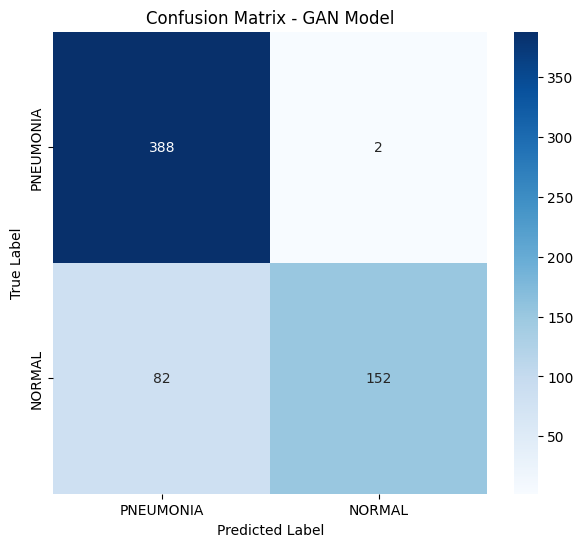


Saved confusion matrix to:
/content/drive/MyDrive/generative_ai_project/results/confusion_test_mapped.png


In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report

# =====================================================
# CONFIG
# =====================================================

IMAGE_SIZE = 128

TEST_DIR = '/content/drive/MyDrive/chest_xray/test'

MODEL_PATH = '/content/drive/MyDrive/generative_ai_project/classifier_final/best_model.pth'

SAVE_DIR = '/content/drive/MyDrive/generative_ai_project/results'

os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Device:", DEVICE)

# =====================================================
# TRANSFORMS
# =====================================================

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# =====================================================
# LOAD TEST DATA
# =====================================================

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Classes:", test_dataset.classes)

# =====================================================
# MODEL
# =====================================================

model = models.densenet121(weights=None)

model.features.conv0 = nn.Conv2d(
    1,
    64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 1)

# =====================================================
# LOAD WEIGHTS
# =====================================================

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

if isinstance(checkpoint, dict):

    if 'model' in checkpoint:
        state_dict = checkpoint['model']

    elif 'state_dict' in checkpoint:
        state_dict = checkpoint['state_dict']

    else:
        state_dict = checkpoint

else:
    state_dict = checkpoint

model.load_state_dict(state_dict)

model = model.to(DEVICE)
model.eval()

print("Model loaded.")

# =====================================================
# PREDICTION
# =====================================================

all_preds = []
all_labels = []

normal_idx = test_dataset.class_to_idx['NORMAL']

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        logits = model(images)

        probs = torch.sigmoid(logits)

        preds = (probs > 0.35).long().cpu().numpy().flatten()

        labels = (labels == normal_idx).long().numpy().flatten()

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

# =====================================================
# REPORT
# =====================================================

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=['PNEUMONIA', 'NORMAL']
    )
)

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['PNEUMONIA', 'NORMAL'],
    yticklabels=['PNEUMONIA', 'NORMAL']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix - GAN Model")

save_path = os.path.join(
    SAVE_DIR,
    'confusion_test_mapped.png'
)

plt.savefig(
    save_path,
    bbox_inches='tight',
    dpi=300
)

plt.show()

print("\nSaved confusion matrix to:")
print(save_path)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  w

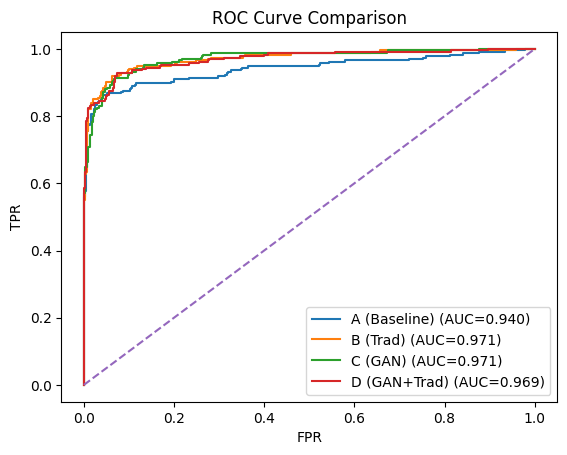

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  w

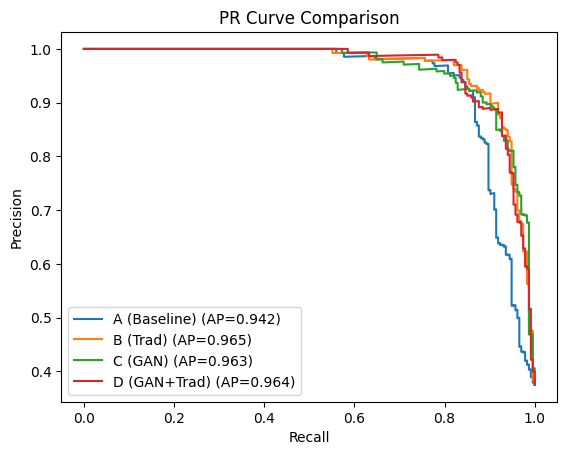

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import torch.nn as nn

# ===== CONFIG =====
IMAGE_SIZE = 128
TEST_DIR = '/content/drive/MyDrive/chest_xray/test'

MODELS = {
    "A (Baseline)": "/content/drive/MyDrive/generative_ai_project/classifier_final_A/best_model.pth",
    "B (Trad)": "/content/drive/MyDrive/generative_ai_project/classifier_final_B/best_model.pth",
    "C (GAN)": "/content/drive/MyDrive/generative_ai_project/classifier_final/best_model.pth",
    "D (GAN+Trad)": "/content/drive/MyDrive/generative_ai_project/classifier_final_D/best_model.pth"
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ===== DATA =====
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.ImageFolder(TEST_DIR, transform=transform)
loader = DataLoader(dataset, batch_size=32)

normal_idx = dataset.class_to_idx['NORMAL']

# ===== FUNCTION =====
def load_model(path):
    model = models.densenet121(pretrained=False)
    model.features.conv0 = nn.Conv2d(1,64,7,2,3,bias=False)
    model.classifier = nn.Linear(model.classifier.in_features, 1)
    model.load_state_dict(torch.load(path, map_location=device))
    return model.to(device).eval()

# ===== PLOTS =====
plt.figure()
for name, path in MODELS.items():
    model = load_model(path)

    labels_all, probs_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            y = (y == normal_idx).numpy()

            probs_all.extend(probs)
            labels_all.extend(y)

    labels_all = np.array(labels_all)
    probs_all = np.array(probs_all)

    # ROC
    fpr, tpr, _ = roc_curve(labels_all, probs_all)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


# ===== PR CURVE =====
plt.figure()
for name, path in MODELS.items():
    model = load_model(path)

    labels_all, probs_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            y = (y == normal_idx).numpy()

            probs_all.extend(probs)
            labels_all.extend(y)

    labels_all = np.array(labels_all)
    probs_all = np.array(probs_all)

    precision, recall, _ = precision_recall_curve(labels_all, probs_all)
    pr_auc = average_precision_score(labels_all, probs_all)

    plt.plot(recall, precision, label=f"{name} (AP={pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve Comparison")
plt.legend()
plt.show()

# Streamlit Deployment

In [ ]:
%%writefile /content/drive/MyDrive/generative_ai_project/app/model_utils.py

from functools import lru_cache
import os
from typing import Dict

import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms

# =========================
# GLOBAL CONFIG
# =========================
BASE_DIR = "/content/drive/MyDrive/generative_ai_project"
IMAGE_SIZE = 128
THRESHOLD = 0.35

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# If your checkpoints use a different folder name, change only these paths.
MODEL_PATHS: Dict[str, str] = {
    "Baseline (A)": os.path.join(BASE_DIR, "classifier_final_A", "best_model.pth"),
    "Traditional Augmentation (B)": os.path.join(BASE_DIR, "classifier_final_B", "best_model.pth"),
    "GAN Augmentation (C)": os.path.join(BASE_DIR, "classifier_final", "best_model.pth"),
    "GAN + Traditional (D)": os.path.join(BASE_DIR, "classifier_final_D", "best_model.pth"),
}

# In your final trained classifiers, higher probability corresponds to NORMAL.
# If one checkpoint behaves inverted, change this constant.
HIGH_PROB_LABEL = "NORMAL"

# =========================
# PREPROCESSING
# =========================
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# =========================
# MODEL DEFINITION
# =========================
def build_model() -> nn.Module:
    model = models.densenet121(weights=None)

    # Adapt first conv layer for grayscale input
    model.features.conv0 = nn.Conv2d(
        1, 64, kernel_size=7, stride=2, padding=3, bias=False
    )

    # Binary classification head
    num_features = model.classifier.in_features
    model.classifier = nn.Linear(num_features, 1)

    return model


def _extract_state_dict(checkpoint):
    """
    Supports:
    - plain state_dict
    - checkpoint dict with keys like 'model', 'state_dict', 'model_state_dict'
    """
    if isinstance(checkpoint, dict):
        for key in ["state_dict", "model_state_dict", "model", "net"]:
            if key in checkpoint and isinstance(checkpoint[key], dict):
                return checkpoint[key]

        # If dict values are all tensors, it likely already is a state_dict
        if all(torch.is_tensor(v) for v in checkpoint.values()):
            return checkpoint

    return checkpoint


def _clean_state_dict_keys(state_dict):
    """
    Removes 'module.' prefix if the checkpoint was saved using DataParallel.
    """
    cleaned = {}
    for k, v in state_dict.items():
        new_k = k.replace("module.", "", 1) if k.startswith("module.") else k
        cleaned[new_k] = v
    return cleaned


@lru_cache(maxsize=8)
def load_model(model_name: str) -> nn.Module:
    if model_name not in MODEL_PATHS:
        raise ValueError(
            f"Unknown model '{model_name}'. Available: {list(MODEL_PATHS.keys())}"
        )

    model_path = MODEL_PATHS[model_name]
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model checkpoint not found: {model_path}")

    model = build_model()

    try:
        checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
    except TypeError:
        checkpoint = torch.load(model_path, map_location=DEVICE)
    except Exception:
        checkpoint = torch.load(model_path, map_location=DEVICE)

    state_dict = _extract_state_dict(checkpoint)
    if isinstance(state_dict, dict):
        state_dict = _clean_state_dict_keys(state_dict)

    model.load_state_dict(state_dict, strict=True)
    model = model.to(DEVICE)
    model.eval()
    return model


@torch.inference_mode()
def predict_image(image: Image.Image, model_name: str, threshold: float = THRESHOLD):
    """
    Returns:
        dict with:
            label: NORMAL or PNEUMONIA
            confidence: confidence of predicted class
            probability: raw sigmoid probability
    """
    model = load_model(model_name)

    x = transform(image).unsqueeze(0).to(DEVICE)
    logits = model(x)
    prob = torch.sigmoid(logits).item()

    if HIGH_PROB_LABEL == "NORMAL":
        label = "NORMAL" if prob >= threshold else "PNEUMONIA"
        confidence = prob if label == "NORMAL" else (1.0 - prob)
    else:
        label = "PNEUMONIA" if prob >= threshold else "NORMAL"
        confidence = prob if label == "PNEUMONIA" else (1.0 - prob)

    return {
        "label": label,
        "confidence": confidence,
        "probability": prob,
    }

In [ ]:
!pip install streamlit pyngrok --quiet

In [ ]:
%%writefile /content/drive/MyDrive/generative_ai_project/app/app.py

import os
from PIL import Image

import pandas as pd
import streamlit as st

from model_utils import (
    MODEL_PATHS,
    predict_image,
)

# =========================
# PAGE CONFIG
# =========================
st.set_page_config(
    page_title="AI Pneumonia Detection",
    page_icon="🩺",
    layout="wide",
    initial_sidebar_state="expanded",
)

# =========================
# PATHS
# =========================
BASE_DIR = "/content/drive/MyDrive/generative_ai_project"
RESULTS_DIR = os.path.join(BASE_DIR, "results")
GENERATE_DIR = os.path.join(
    BASE_DIR,
    "generated_images",
    "filtered_NORMAL"
)

# =========================
# RESULT FILES
# =========================

ROC_PATH = os.path.join(
    RESULTS_DIR,
    "roc_curve.png"
)

PR_PATH = os.path.join(
    RESULTS_DIR,
    "pr_curve.png"
)

CM_PATH = os.path.join(
    RESULTS_DIR,
    "confusion_test_mapped.png"
)

# =========================
# GAN IMAGE GALLERY
# =========================

GAN_IMAGES = []

if os.path.exists(GENERATE_DIR):

    GAN_IMAGES = sorted([
        os.path.join(GENERATE_DIR, f)
        for f in os.listdir(GENERATE_DIR)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

# =========================
# CUSTOM CSS
# =========================
st.markdown(
    """
    <style>
    .stApp {
        background: #0b1220;
        color: #e5e7eb;
    }

    .main-title {
        font-size: 2.4rem;
        font-weight: 800;
        color: #f8fafc !important;
        margin-bottom: 0.25rem;
    }

    .sub-title {
        font-size: 1rem;
        color: #cbd5e1 !important;
        margin-bottom: 1rem;
    }

    .card {
        background: #111827;
        padding: 1rem 1.1rem;
        border-radius: 16px;
        border: 1px solid #334155;
        box-shadow: 0 4px 18px rgba(0, 0, 0, 0.15);
        color: #e5e7eb !important;
        min-height: 95px;
    }

    .card h4, .card p, .card b, .card div, .card span {
        color: #e5e7eb !important;
        margin: 0;
    }

    .small-label {
        font-size: 0.85rem;
        color: #94a3b8 !important;
        margin-bottom: 0.25rem;
        font-weight: 700;
        letter-spacing: 0.02em;
    }

    .result-box {
        padding: 1rem 1.2rem;
        border-radius: 16px;
        font-size: 1.15rem;
        font-weight: 800;
        text-align: center;
        border: 1px solid #334155;
        background: #111827;
        color: #f8fafc !important;
    }

    .normal-box {
        background: #052e16;
        color: #bbf7d0 !important;
        border: 1px solid #166534;
    }

    .pneumonia-box {
        background: #450a0a;
        color: #fecaca !important;
        border: 1px solid #991b1b;
    }

    .info-note {
        background: #111827;
        border: 1px solid #334155;
        border-radius: 16px;
        padding: 0.9rem 1rem;
        color: #e5e7eb;
    }

    .soft-divider {
        border-top: 1px solid #1f2937;
        margin-top: 0.5rem;
        margin-bottom: 0.5rem;
    }
    </style>
    """,
    unsafe_allow_html=True,
)

# =========================
# SIDEBAR
# =========================
st.sidebar.title("🩻 Project Info")
st.sidebar.markdown(
    """
**Project:** Generative AI for Medical Data Augmentation
**Task:** Pneumonia detection from chest X-rays
**Classifier:** DenseNet121
**Environment:** Google Colab + Streamlit
**Storage:** Google Drive
"""
)

selected_model = st.sidebar.selectbox(
    "Select Model",
    options=list(MODEL_PATHS.keys()),
    index=1,  # default: Traditional Augmentation (B)
)

threshold = st.sidebar.slider(
    "Prediction Threshold",
    min_value=0.10,
    max_value=0.90,
    value=0.35,
    step=0.01,
)

st.sidebar.markdown("### How to use")
st.sidebar.markdown(
    """
1. Upload a chest X-ray image
2. Select a model
3. Click **Predict**
4. View the result and confidence
5. Explore the GAN training story and performance plots
"""
)

st.sidebar.warning(
    "This is a research prototype and is not a clinical diagnostic tool."
)

# =========================
# HEADER
# =========================
st.markdown(
    '<div class="main-title">🩺 AI Pneumonia Detection System</div>',
    unsafe_allow_html=True,
)
st.markdown(
    """
    <div class="sub-title">
    Upload a chest X-ray image, choose a trained classifier, and get a real-time prediction.
    </div>
    """,
    unsafe_allow_html=True,
)

c1, c2, c3 = st.columns([1.5, 1, 1.2])
with c1:
    st.markdown(
        """
        <div class="card">
            <div class="small-label">Pipeline</div>
            <b>GAN augmentation → filtered synthetic data → DenseNet121 classifier → web UI</b>
        </div>
        """,
        unsafe_allow_html=True,
    )
with c2:
    st.markdown(
        f"""
        <div class="card">
            <div class="small-label">Selected model</div>
            <b>{selected_model}</b>
        </div>
        """,
        unsafe_allow_html=True,
    )
with c3:
    st.markdown(
        f"""
        <div class="card">
            <div class="small-label">Threshold</div>
            <b>{threshold:.2f}</b>
        </div>
        """,
        unsafe_allow_html=True,
    )

st.markdown('<div class="soft-divider"></div>', unsafe_allow_html=True)

# =========================
# TABS
# =========================
tab1, tab2, tab3, tab4 = st.tabs(
    ["🔍 Predict", "📊 Performance", "🧠 GAN Training Story", "ℹ️ About Project"]
)

# =========================
# TAB 1: PREDICT
# =========================
with tab1:
    left, right = st.columns([1.05, 0.95], gap="large")

    with left:
        st.markdown("### Upload Chest X-ray")
        uploaded_file = st.file_uploader(
            "Choose a PNG, JPG or JPEG image",
            type=["png", "jpg", "jpeg"],
        )

        if uploaded_file is not None:
            image = Image.open(uploaded_file).convert("RGB")
            st.image(image, caption="Uploaded X-ray", use_container_width=True)

            predict_clicked = st.button("Predict", use_container_width=True)

            if predict_clicked:
                with st.spinner("Analyzing image..."):
                    try:
                        result = predict_image(image, selected_model, threshold=threshold)
                        st.session_state["prediction_result"] = result
                    except Exception as e:
                        st.session_state["prediction_result"] = None
                        st.error(f"Prediction failed: {e}")

    with right:
        st.markdown("### Result")
        result = st.session_state.get("prediction_result", None)

        if result:
            label = result["label"]
            confidence = result["confidence"]
            probability = result["probability"]

            if label == "PNEUMONIA":
                st.markdown(
                    f'<div class="result-box pneumonia-box">Prediction: {label}</div>',
                    unsafe_allow_html=True,
                )
            else:
                st.markdown(
                    f'<div class="result-box normal-box">Prediction: {label}</div>',
                    unsafe_allow_html=True,
                )

            st.write("")
            st.metric("Confidence", f"{confidence * 100:.2f}%")
            st.progress(float(confidence))
            st.caption(f"Raw model probability: {probability:.4f}")
        else:
            st.markdown(
                """
                <div class="info-note">
                    Upload an image and press <b>Predict</b> to see the result here.
                </div>
                """,
                unsafe_allow_html=True,
            )

# =========================
# TAB 2: PERFORMANCE
# =========================
with tab2:
    st.markdown("### Final Model Comparison")

    perf_df = pd.DataFrame(
        [
            ["Baseline (A)", 0.82, 0.53, 1.00, 0.78],
            ["Traditional Augmentation (B)", 0.88, 0.71, 0.99, 0.87],
            ["GAN Augmentation (C)", 0.87, 0.65, 0.99, 0.84],
            ["GAN + Traditional (D)", 0.88, 0.68, 0.99, 0.86],
        ],
        columns=["Model", "Accuracy", "NORMAL Recall", "PNEUMONIA Recall", "Macro F1"],
    )
    st.table(perf_df)

    st.markdown("### Evaluation Plots")
    p1, p2 = st.columns(2)

    with p1:
        if os.path.exists(ROC_PATH):
            st.image(ROC_PATH, caption="ROC Curve", use_container_width=True)
        else:
            st.warning("ROC curve not found.")

    with p2:
        if os.path.exists(PR_PATH):
            st.image(PR_PATH, caption="Precision-Recall Curve", use_container_width=True)
        else:
            st.warning("Precision-Recall curve not found.")

    st.write("")
    if os.path.exists(CM_PATH):
        st.markdown("### Confusion Matrix")
        st.image(CM_PATH, caption="Confusion Matrix", use_container_width=True)

    st.markdown(
        """
        **Why these plots matter**
        - ROC shows class separation across thresholds.
        - PR curve is important for imbalanced medical data.
        - Confusion matrix shows correct and incorrect predictions.
        """
    )

# =========================
# TAB 3: GAN TRAINING STORY
# =========================

with tab3:

    st.markdown("## 🧠 GAN Training Story")

    st.markdown(
        """
        This project uses a **WGAN-GP (Wasserstein GAN with Gradient Penalty)** to generate synthetic
        NORMAL chest X-ray images.

        The generated images are filtered using DenseNet121 feature similarity before
        being used for classifier training.
        """
    )

    m1, m2, m3 = st.columns(3)

    with m1:
        st.metric("Training Epochs", "110")

    with m2:
        st.metric("Generated Images", "2500")

    with m3:
        st.metric("Filtered Images Used", "2000")

    st.markdown("---")

    st.subheader("Pipeline")

    st.markdown(
        """
        Real NORMAL X-rays
        ➜ WGAN-GP Training
        ➜ 2500 Synthetic Images
        ➜ DenseNet Feature Filtering
        ➜ Best 2000 Images
        ➜ DenseNet121 Classifier
        """
    )

    st.markdown("---")

    st.subheader("GAN Generated Samples")

    if len(GAN_IMAGES) > 0:

        import random

        sample_imgs = random.sample(
            GAN_IMAGES,
            min(6, len(GAN_IMAGES))
        )

        cols = st.columns(3)

        for idx, img_path in enumerate(sample_imgs):

            with cols[idx % 3]:

                st.image(
                    img_path,
                    use_container_width=True
                )

    else:

        st.warning("No GAN images found.")

    st.markdown("---")

    st.info(
        """
        The GAN was trained on NORMAL chest X-rays only.

        After training, 2500 synthetic images were generated.
        DenseNet121 feature filtering was then used to retain the
        2000 most realistic images for augmentation.
        """
    )

# =========================
# TAB 4: ABOUT PROJECT
# =========================
with tab4:
    st.markdown("### Project Overview")

    a, b, c = st.columns(3)
    with a:
        st.markdown(
            """
            <div class="card">
                <h4>1. GAN Training</h4>
                <p>The WGAN-GP learns to generate realistic NORMAL chest X-ray images.</p>
            </div>
            """,
            unsafe_allow_html=True,
        )
    with b:
        st.markdown(
            """
            <div class="card">
                <h4>2. Filtering</h4>
                <p>Generated images are filtered using DenseNet121 feature similarity.</p>
            </div>
            """,
            unsafe_allow_html=True,
        )
    with c:
        st.markdown(
            """
            <div class="card">
                <h4>3. Classification</h4>
                <p>The final DenseNet121 classifier is trained using real and synthetic data.</p>
            </div>
            """,
            unsafe_allow_html=True,
        )

    st.write("")
    st.markdown("### Final Experiment Setup")
    st.markdown(
        """
        - **Model A:** No augmentation
        - **Model B:** Traditional augmentation only
        - **Model C:** GAN augmentation only
        - **Model D:** GAN + Traditional augmentation
        """
    )

    st.write("")
    st.info(
        "This project demonstrates an end-to-end Generative AI pipeline for medical image augmentation and pneumonia detection."
    )

    st.write("")
    st.markdown("### Model Selection")
    st.markdown(
        f"""
        Current selected model for prediction: **{selected_model}**
        """
    )

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("NGROK_TOKEN")

In [ ]:
!streamlit run /content/drive/MyDrive/generative_ai_project/app/app.py &>/content/logs.txt &

In [ ]:
public_url = ngrok.connect(8501)

print(public_url)